**Problem Statement**

Behavioral Segmentation for Targeted Marketing
Statement:

Businesses group customers based on purchasing power to tailor marketing
efforts. Students will generate a 150-row retail dataset featuring Annual_Spending and
Purchase_Frequency. The project involves StandardScaler and the K-Means Clustering
algorithm to identify customer "personas."
Pipeline: Retail Data Synthesis --> StandardScaler --> K-Means --> Elbow Method
Visualization.

---

1. **Import libraries**

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

---

2. **Loading DataSet**



In [158]:
df=pd.read_csv("dataset.csv")
df.head()

,Customer_ID,Gender,City,City_Tier,Annual_Income,Annual_Spending,Purchase_Frequency
0,1,Male,Chennai,1.0,4.137690e+06,1.215936e+06,38.937976
1,2,Male,Jabalpur,3.0,9.319119e+05,1.935790e+05,25.171201
2,3,Male,Lucknow,2.0,6.188340e+05,1.168110e+05,39.112999
3,4,Male,Chandigarh,2.0,7.148351e+05,2.307010e+05,22.990749
4,5,Male,Jaipur,2.0,6.967691e+05,2.603871e+05,24.054294


---

3. **Start of EDA**

In [159]:
df.isna().sum()

,0
Customer_ID,0
Gender,0
City,19
City_Tier,17
Annual_Income,17
Annual_Spending,16
Purchase_Frequency,17


- Fill NA Values

In [160]:
df=df.fillna({"Annual_Income":df['Annual_Income'].mean(),"Annual_Spending":df['Annual_Spending'].mean(),"Purchase_Frequency":df['Purchase_Frequency'].mean()})

- Drop not necessary features

In [161]:
df_model=df.drop(columns=["City","City_Tier","Customer_ID","Gender"])
df_model.isna().sum()

,0
Annual_Income,0
Annual_Spending,0
Purchase_Frequency,0


In [162]:
df_model.head()

,Annual_Income,Annual_Spending,Purchase_Frequency
0,4.137690e+06,1.215936e+06,38.937976
1,9.319119e+05,1.935790e+05,25.171201
2,6.188340e+05,1.168110e+05,39.112999
3,7.148351e+05,2.307010e+05,22.990749
4,6.967691e+05,2.603871e+05,24.054294


In [163]:
df_model.info()
df_model.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Annual_Income       285 non-null    float64
 1   Annual_Spending     285 non-null    float64
 2   Purchase_Frequency  285 non-null    float64
dtypes: float64(3)
memory usage: 6.8 KB


,Annual_Income,Annual_Spending,Purchase_Frequency
count,2.850000e+02,2.850000e+02,285.000000
mean,2.191237e+06,6.063367e+05,35.391780
std,1.976993e+06,5.408068e+05,18.981814
min,2.500149e+05,6.104098e+04,4.876134
25%,8.246741e+05,2.307010e+05,23.014434
50%,1.631565e+06,4.657309e+05,32.879968
75%,2.448260e+06,7.649111e+05,42.913025
max,1.039397e+07,2.969988e+06,110.235708


- Outlier Detection

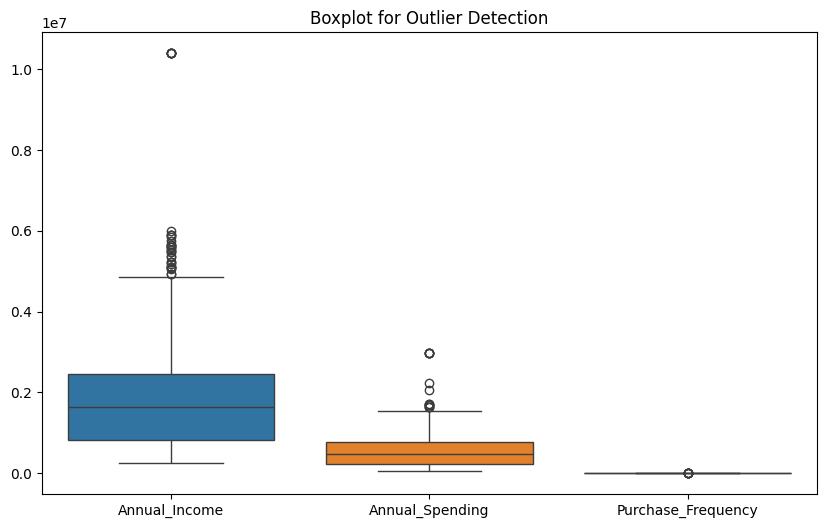

In [164]:
plt.figure(figsize=(10,6))
sb.boxplot(data=df_model)
plt.title("Boxplot for Outlier Detection")
plt.show()

**Apply log transformation**

In [165]:
df_model['Annual_Income'] = np.log1p(df_model['Annual_Income'])
df_model['Annual_Spending'] = np.log1p(df_model['Annual_Spending'])
df_model['Purchase_Frequency'] = np.log1p(df_model['Purchase_Frequency'])

**Check Effectiveness of log transform**

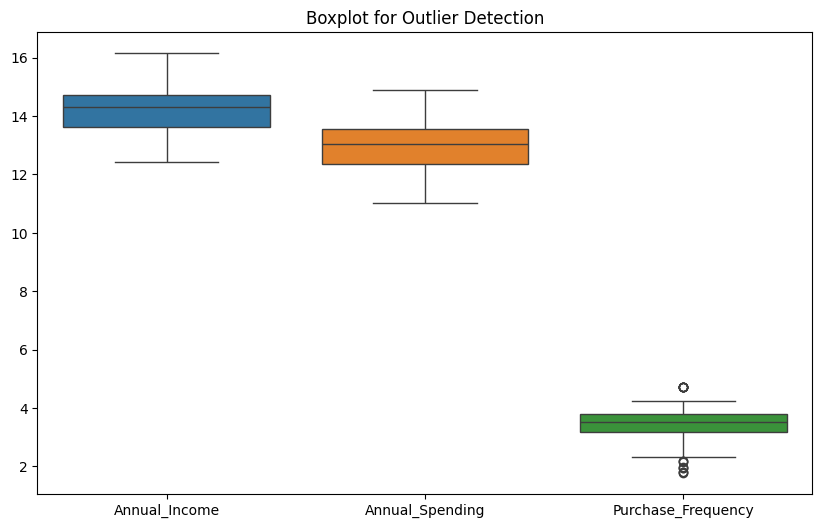

In [166]:
plt.figure(figsize=(10,6))
sb.boxplot(data=df_model)
plt.title("Boxplot for Outlier Detection")
plt.show()

array([[<Axes: title={'center': 'Annual_Income'}>,
        <Axes: title={'center': 'Annual_Spending'}>],
       [<Axes: title={'center': 'Purchase_Frequency'}>, <Axes: >]],
      dtype=object)

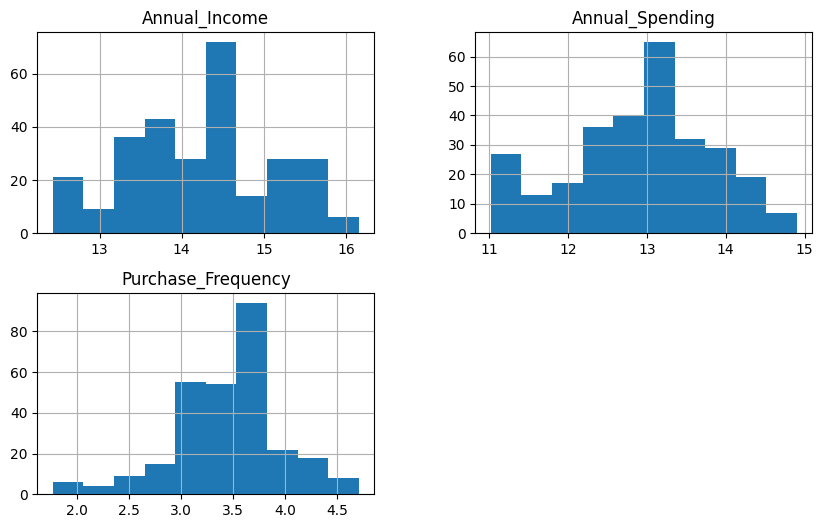

In [167]:
df_model.hist(figsize=(10,6))

- Outlier removal

In [168]:
for col in ['Annual_Income','Annual_Spending','Purchase_Frequency']:
    q1=df_model[col].quantile(0.25)
    q3=df_model[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df_model=df_model[(df_model[col]>=lower) & (df_model[col]<=upper)]

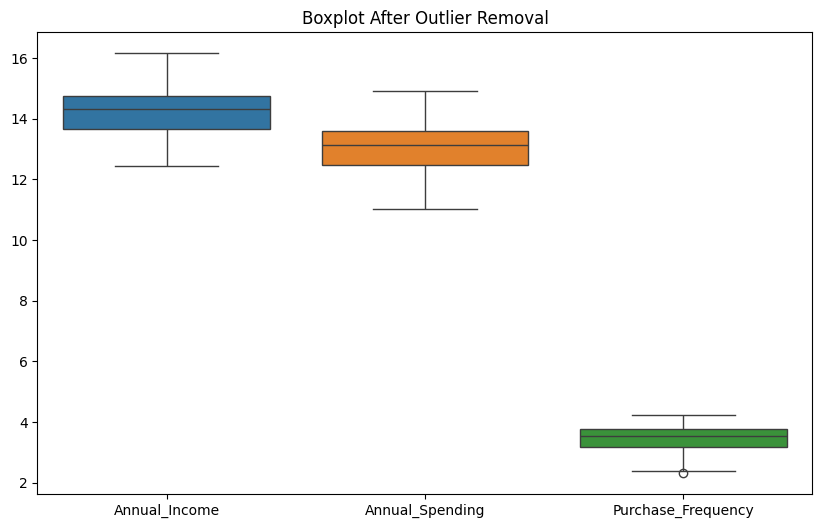

In [169]:
plt.figure(figsize=(10,6))
sb.boxplot(data=df_model)
plt.title("Boxplot After Outlier Removal")
plt.show()

**Correlation**

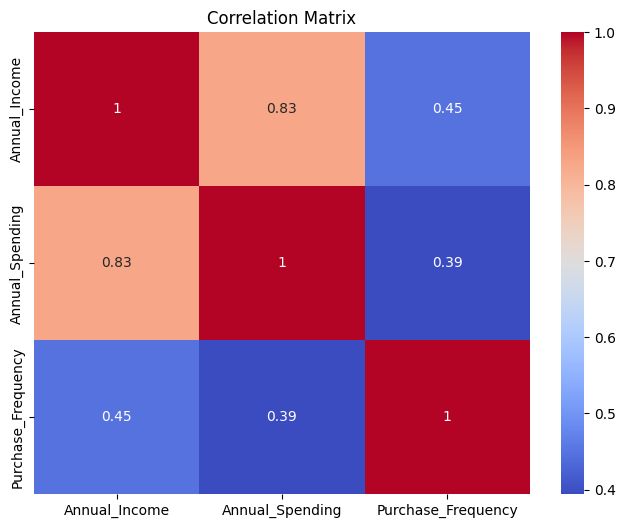

In [170]:
plt.figure(figsize=(8,6))
sb.heatmap(df_model.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- Correlation matrix shows high multicollinearity (0.83), making features acceptable for K-Means but not ideal.

In [171]:
df_model["Spending_Score"]=df_model["Annual_Spending"]/df_model["Annual_Income"]

**Scaling Features**

In [172]:
ss = StandardScaler()
x = ss.fit_transform(df_model)

**Elbow Graph**

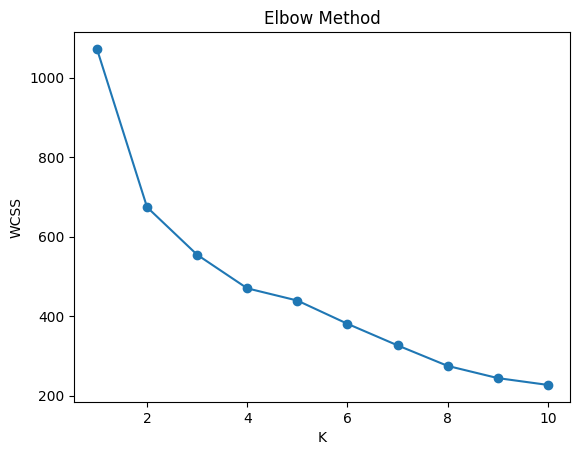

In [173]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

- Finding Optimal Value of k

In [174]:
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x)
    print(f"K:{k} -> {silhouette_score(x, labels):.3f}")

K:2 -> 0.337
K:3 -> 0.275
K:4 -> 0.297
K:5 -> 0.315
K:6 -> 0.321
K:7 -> 0.332
K:8 -> 0.324
K:9 -> 0.329
K:10 -> 0.339


Selecting K=5 as optimal number of cluster

In [175]:
best_k=5

In [176]:
df_model.to_csv("dataset(post).csv",index=False)
print("Phase 1 Completed")

Phase 1 Completed


Applying KMeans

In [177]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_model["Cluster"] = kmeans.fit_predict(x)

Clustering

In [178]:
df_model.groupby("Cluster")[["Spending_Score", "Purchase_Frequency"]].mean()

,Spending_Score,Purchase_Frequency
Cluster,,
0,0.907629,3.757345
1,1.018999,3.096391
2,0.876958,3.234801
3,0.912089,3.050329
4,0.916600,3.705431


In [179]:
clusters = df_model.groupby("Cluster").agg({"Spending_Score": "mean","Purchase_Frequency": "mean"}).reset_index()
clisters=clusters.sort_values(by=["Spending_Score", "Purchase_Frequency"],ascending=False).reset_index(drop=True)
print(clusters)

   Cluster  Spending_Score  Purchase_Frequency
0        0        0.907629            3.757345
1        1        1.018999            3.096391
2        2        0.876958            3.234801
3        3        0.912089            3.050329
4        4        0.916600            3.705431


In [194]:
labels = ["High-Value Loyal (Premium)", "High Spenders (Occasional)", "Low Engagement", "Frequent Budget", "High-Value Loyal (Standard)"]
clusters = clusters.sort_values("Cluster").reset_index(drop=True)
clusters["Persona"] = labels

In [195]:
per = dict(zip(clusters["Cluster"], clusters["Persona"]))
df_model["Persona"] = df_model["Cluster"].map(per)
df_model["Persona"].value_counts()

,count
Persona,
High-Value Loyal (Standard),93
High-Value Loyal (Premium),65
Frequent Budget,57
Low Engagement,43
High Spenders (Occasional),10


**Customer Profiling**

In [196]:
profile=df_model.groupby("Cluster").agg({"Spending_Score": "mean","Purchase_Frequency": "mean"}).round(2)
profile

,Spending_Score,Purchase_Frequency
Cluster,,
0,0.91,3.76
1,1.02,3.10
2,0.88,3.23
3,0.91,3.05
4,0.92,3.71


**Customer Segmentation Graph**

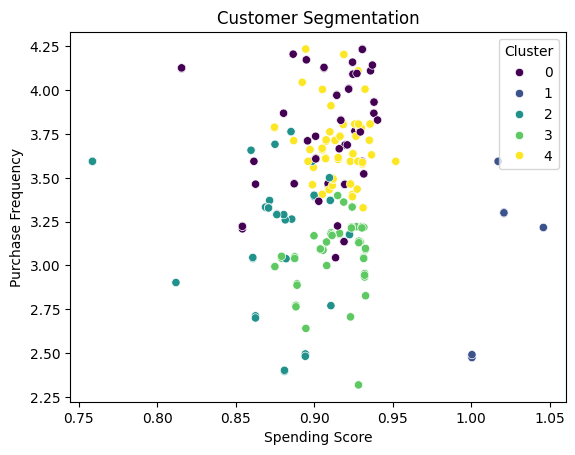

In [186]:
sb.scatterplot(x=df_model["Spending_Score"],y=df_model["Purchase_Frequency"],hue=df_model["Cluster"],palette="viridis")
plt.title("Customer Segmentation")
plt.xlabel("Spending Score")
plt.ylabel("Purchase Frequency")
plt.show()

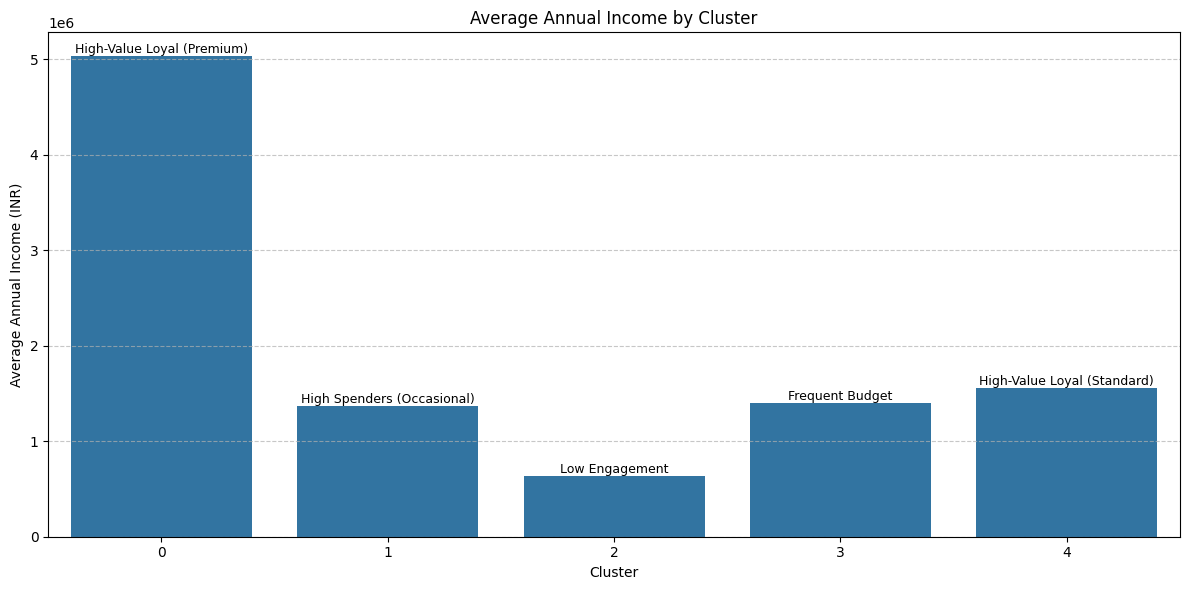

In [198]:
clusters = df_model.groupby("Cluster").agg({"Spending_Score": "mean","Purchase_Frequency": "mean","Annual_Income": lambda x: np.expm1(x).mean()}).reset_index()
clusters["Persona"] = clusters["Cluster"].map(per)

plt.figure(figsize=(12, 6))
sb.barplot(x="Cluster",y="Annual_Income",data=clusters)

plt.title("Average Annual Income by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Annual Income (INR)")

for i, row in clusters.iterrows():
  plt.text(i,row["Annual_Income"],row["Persona"],ha="center",va="bottom",fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()